# FS→DSA Final Analysis — Austria

This notebook guides through an analysis of Austria's MTP and the implications of policy-dependent potential output within the DSA. It can be run top-to-bottom without prior knowledge of the codebase. 

What the notebook will do:
- Load the FS and DSA models. For this excercise, only the supply block of the FS model is relevant: with no structural changes in taxation, the FS supply block is basically equivalent to the key trend equations in the PREM model.
- Enter MTP-informed baseline paths (SPB, potential growth & inflation)
    - Reasoning: We are asusming that the policies named in the MTP are consistent with the specified potential output and inflation paths. I.e.: The specified policy mix will lead to the specified macroeconomic conditions.
    - As GDP is endogenously calculated in the DSA based on PO and output gap, we do not use the (already endogenous) GDP path from the MTP as the baseline.
- Evaluate whether the SPB path from the MTP is still the binding SPB path given newly available data.
- Find the actual binding SPB path to form our baseline.
- Calibrate FS baseline to DSA.
- Run a policy scenario in FS and port it back to DSA.
- Compute the binding SPB path under different potential output assumptuons and compare baseline and scenario SPB target (fiscal space assessment)


## 1) Setup and imports

In [34]:
import sys, warnings, copy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
warnings.filterwarnings('ignore')

# Add the model directories to Python path
sys.path.append('model/fs')
sys.path.append('model/dsa/code/classes')

# Direct imports (no package structure)
from data_functions import load_and_process_data
from model_equations import build_model
from scenario_functions import initialize_model, run_scenario_analysis
from integration import apply_mtp_anchors_to_dsa, apply_fs_potential_to_dsa, run_dsa_with_potential_and_spb
from StochasticDsaModelClass import StochasticDsaModel as DSA

# Analysis toggles
START, END = 2025, 2041

## 2) Import data
Load FS data and prepare the DSA model. 

In [35]:
AT = load_and_process_data(data_folder='data', sheet_name='Austria')
FS_model = build_model(include_fiscal=True, include_kg_lag=False)
data_AT = FS_model.insertModelVar(AT)
print('AT data shape:', AT.shape)

# set output gap mechanism in private investment = 0 as we dont assume this effect in PREM yet (all other variables affecting private investment dont change, so no need to adjust them)
data_AT.loc[:, 'LAMBDA_IQ_M_4'] = 0

dsa_at = DSA(country='AUT', start_year=2024, end_year=2041, adjustment_period=7, adjustment_start_year=2025, fiscal_multiplier_type='ec')
dsa_at.project()  # seed baseline arrays
df_at = dsa_at.df(all=True)

AT data shape: (84, 223)


## 3) Specify MTP paths (SPB, potential growth, inflation) and policy measures
The dictionaries below can be edited to specify different assumptions.
- SPB: level path (% of GDP)
- rg_pot: potential GDP growth (percent)
- pi: GDP deflator inflation (percent); available only up to 2029/2031 — we auto-align later years


In [36]:
years_full = list(range(dsa_at.start_year, dsa_at.end_year + 1))

# --- SPB level path from MTP, constant after ---
mtfp_spb_points = {
    2024: -2.40, 2025: -1.90, 2026: -1.40, 2027: -0.80, 2028: -0.20,
    2029: 0.40, 2030: 0.80, 2031: 1.20
}
mtfp_spb = pd.Series(mtfp_spb_points).reindex(years_full).interpolate().ffill()

# --- Potential GDP growth anchors constant after ---
mtfp_rg_pot_points = {
    2025: 1.1, 2026: 1.1, 2027: 1.1, 2028: 1.1, 2029: 1.1, 2030: 1.1, 2031: 1.1
}
mtfp_rg_pot = pd.Series(mtfp_rg_pot_points).reindex(years_full).interpolate().ffill()

# --- Inflation ---
mtfp_pi_points = {
    2025: 2.4, 2026: 2.0, 2027: 2.1, 2028: 2.1, 2029: 2.1, 2030: 2.2, 2031: 2.2, 2032: 2.3, 2033: 2.3, 2034: 2.4, 2035: 2.3, 2036: 2.3, 2037: 2.3, 2038: 2.3, 2039: 2.3, 2040: 2.2, 2041: 2.2
}


In [37]:
# Apply your MTP inflation and potential growth assumptions
mtp_anchors = {
    'rg_pot': pd.Series(mtfp_rg_pot),  # Potential growth
    'pi': mtfp_pi_points,              # Inflation path
}

# Convert your SPB level path to steps directly
a0 = dsa_at.adjustment_start  # This is 1 (2025)
a1 = dsa_at.adjustment_end    # This is 7 (2031)
years = np.arange(dsa_at.start_year, dsa_at.end_year + 1)  # [2024, 2025, ..., 2045]

# Get your SPB levels aligned to model years
spb_full = mtfp_spb.reindex(years).to_numpy()

# Calculate steps for adjustment period only
spb_steps = np.zeros(dsa_at.adjustment_period)  # Array of 7 zeros
for t in range(a0, a1 + 1):  # t goes from 1 to 7
    spb_steps[t - a0] = spb_full[t] - spb_full[t - 1]

print(f"SPB steps: {spb_steps}")
print(f"SPB levels: {spb_full[1:8]}")  # Show the levels for 2025-2031

SPB steps: [0.5 0.5 0.6 0.6 0.6 0.4 0.4]
SPB levels: [-1.9 -1.4 -0.8 -0.2  0.4  0.8  1.2]


## 4) Initialise baseline

Project the debt ratio with the planned policies, assuming that they will lead to the specified potential output and inflation changes/levels specified in the plan. The same starting value for SPB specified in MTP is also assumed.

In [38]:
dsa_at.spb_bca[0] = -2.4
dsa_at.spb[0] = -2.4
apply_mtp_anchors_to_dsa(dsa_at, anchors=mtp_anchors, inplace=True)
dsa_at.growth_driven_preclosure = False
dsa_at.project(spb_steps=spb_steps)
df_at = dsa_at.df(all=True)


In [39]:
dsa_bl_opt = copy.deepcopy(dsa_at)
dsa_bl_opt.find_spb_binding(print_results=True)
df_bl_opt = dsa_bl_opt.df(all=True)
print(f"SPB: {dsa_at.spb_bca[7]:.2f}% vs Binding: {dsa_bl_opt.binding_spb_target:.2f}% {'✓' if dsa_at.spb_bca[7] >= dsa_bl_opt.binding_spb_target else '✗'}")

                  Model Params                             SPB Targets       
================================================     ========================
country                                      AUT     main_adjustment    0.373
adjustment period                              7     lower_spb          0.865
adjustment start                            2025     financial_stress   0.402
shock frequency                        quarterly     adverse_r_g        1.068
stochastic period                      2032-2037     deficit_reduction  0.213
estimation                                normal     stochastic         0.802
bond level data                            False     edp                1.064
safeguards         EDP, debt, deficit_resilience     binding            1.064
================================================     ========================

                                Binding Params                               
spb_steps                     0.5  , 0.5  , 0.5  , 0.626, 0.446

In [40]:
# Extract rg, rg_pot, pi series from dsa_bl_opt. rg_pot and pi should be the same as in MTP
rg = pd.Series(dsa_bl_opt.rg, index=years, name='rg')
rg_pot = pd.Series(dsa_bl_opt.rg_pot, index=years, name='rg_pot')
pi = pd.Series(dsa_bl_opt.pi, index=years, name='pi')

bl_anchors = {
    'rg': rg,
    'rg_pot': rg_pot,
    'pi': pi
}

Run the FS model and calibrate to result in the real growth, potential growth, and inflation paths of DSA. In our paper, only the supply block calculating potential output is relevant.

In [41]:
baseline_AT = initialize_model(
    data=data_AT, 
    model_class=FS_model, 
    start=START, 
    end=END,
    interest_method='exogenous', 
    baseline_method='DSA_MTP',  # This should use your DSA model
    beta_d_assumption='zero', 
    dsa_model=copy.deepcopy(dsa_bl_opt),  # Use the binding DSA model
    mtp_anchors=bl_anchors,
)


Finding instruments :   0%|          | 0/17

## 5) Scenario analysis
Estimate the impact of the policy measures in the FS model, then port the scenario potential into DSA for comparison.

In [42]:
#interpret: absolute means the value is added to the baseline value in that year, delta means only the change to the previous year is added
#persist: will changes persist after scenario timeframe (e.g., after adjustment period)?
#persist_mode: plateau means no further changes (e.g., if EPS_SR = 0.001, it will be 0 in the following years); 
#              copy_last means the last value copied forward (e.g., if EPS_SR = 0.001, EPS_SR will continue to be 0.001 in the following years)
measures = [
    # Measure 1: Childcare reform -> LP
    { 'var': 'EPS_LP', 'values': [0.0000, 0.01670341, 0.01670341], 'interpret': 'absolute', 'persist': True, 'persist_mode': 'plateau' },
    #{ 'var': 'EPS_H', 'values': [0.0, 0.055, 0.055, 0.055], 'interpret': 'absolute', 'persist': True, 'persist_mode': 'plateau' },

    # Measure 2: Corridor pension -> LP
    { 'var': 'EPS_LP', 'values': [0.0000, 0.0000, 0.06124585, 0.06124585, 0.06124585], 'interpret': 'absolute', 'persist': True, 'persist_mode': 'plateau' },
    
    # Measure 3: Red-White-Red Card -> LP
    { 'var': 'EPS_LP', 'values': [0.0000, 0.0000, 0.0000, 0.08, 0.08], 'interpret': 'asolute', 'persist': True, 'persist_mode': 'plateau' },
]

In [43]:
scenario_AT = run_scenario_analysis(
    baseline_result=baseline_AT, model_class=FS_model,
    scenario_shocks=measures, scenario_name='AT_policy',
)

,Period 1,Period 2,Period 3,Period 4,Period 5
EPS_LP,0.0,0.016703,0.077949,0.141246,0.141246


Finding instruments :   0%|          | 0/3

Finding instruments :   0%|          | 0/7

Calculate a smoothed potential output growth path for better comparison to smoothed PO growth path in MTP.

In [44]:
# Calculate total growth from 2024 to 2041 for Austria (AT)
start_value = baseline_AT.loc[2024, 'Y_STAR']
end_value = scenario_AT.loc[2041, 'Y_STAR']
total_growth_factor = end_value / start_value

# Calculate the constant annual growth rate from 2025 to 2041 (17 years)
years_span = 2041 - 2024  # 17 years
constant_growth_rate = (total_growth_factor ** (1/years_span)) - 1

# Create smoothed Y_STAR series with constant growth
scenario_AT['Y_STAR_smooth'] = scenario_AT['Y_STAR'].copy()
scenario_AT.loc[2024, 'Y_STAR_smooth'] = start_value

# Apply constant growth from 2025 onwards
for year in range(2025, 2042):
    scenario_AT.loc[year, 'Y_STAR_smooth'] = start_value * ((1 + constant_growth_rate) ** (year - 2024))

# Calculate the smoothed growth rates
scenario_AT['Y_STAR_growth_smooth'] = scenario_AT['Y_STAR_smooth'].pct_change() * 100

print(f"Total growth factor: {total_growth_factor:.4f}")
print(f"Constant annual growth rate: {constant_growth_rate*100:.2f}%")
print(f"Growth from 2024 to 2041: {(total_growth_factor-1)*100:.2f}%")

Total growth factor: 1.2091
Constant annual growth rate: 1.12%
Growth from 2024 to 2041: 20.91%


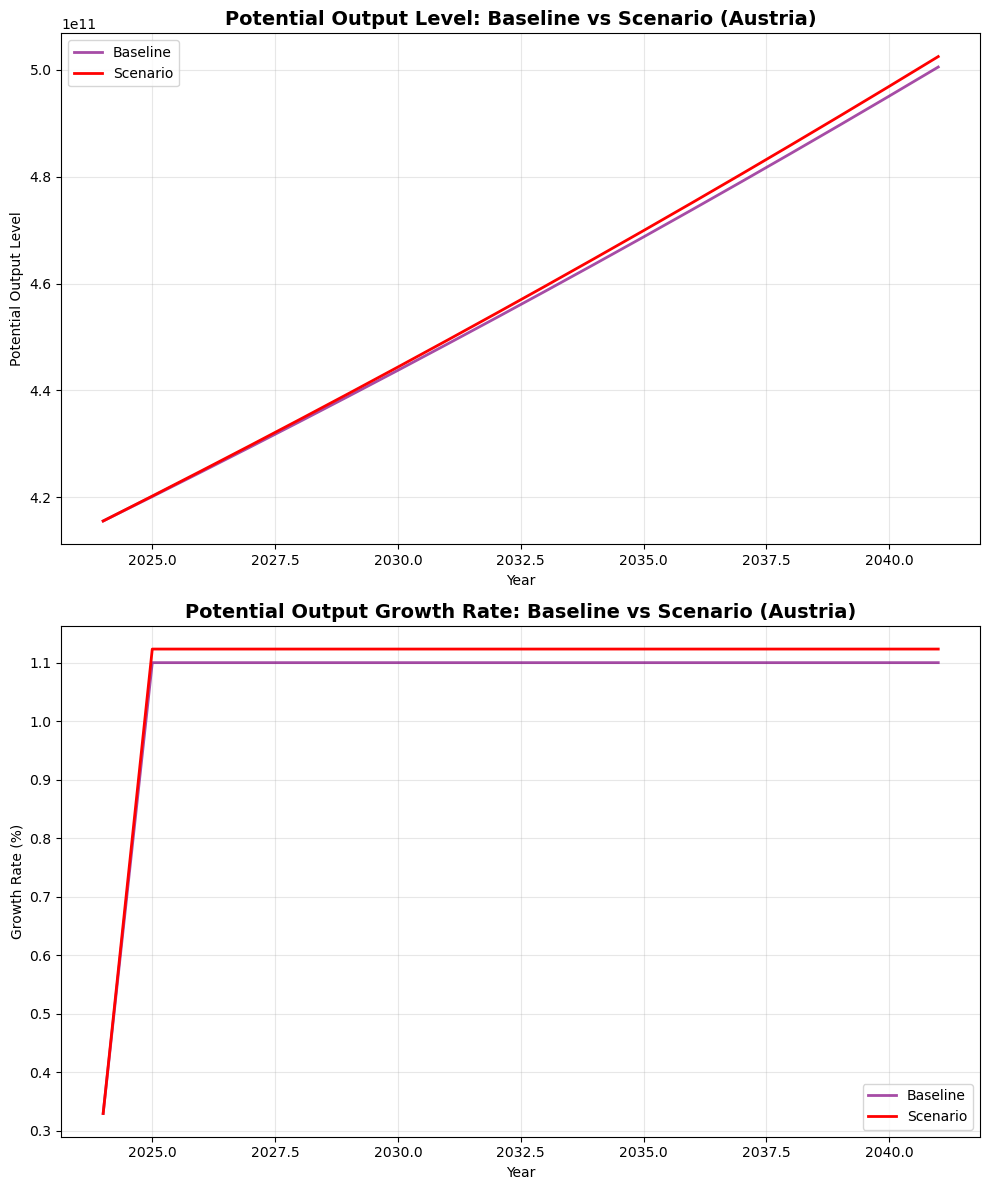

In [45]:
# Compare only baseline vs scenario (smoothed) for Austria
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Define years for x-axis (2024 to 2041)
years_plot = range(2024, 2042)

# First subplot: Baseline vs Scenario (smoothed) Y_STAR levels
ax1.set_title('Potential Output Level: Baseline vs Scenario (Austria)', fontsize=14, fontweight='bold')
ax1.plot(years_plot, baseline_AT.loc[years_plot, 'Y_STAR'], 
         color='purple', linestyle='-', linewidth=2, 
         label='Baseline', alpha=0.7)
ax1.plot(years_plot, scenario_AT.loc[years_plot, 'Y_STAR_smooth'], 
         color='red', linestyle='-', linewidth=2, 
         label='Scenario')
ax1.set_xlabel('Year')
ax1.set_ylabel('Potential Output Level')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Second subplot: Baseline vs Scenario (smoothed) growth rates
ax2.set_title('Potential Output Growth Rate: Baseline vs Scenario (Austria)', fontsize=14, fontweight='bold')
ax2.plot(years_plot, baseline_AT.loc[years_plot, 'G_Y_STAR'], 
         color='purple', linestyle='-', linewidth=2, 
         label='Baseline', alpha=0.7)
ax2.plot(years_plot, scenario_AT.loc[years_plot, 'Y_STAR_growth_smooth'], 
         color='red', linestyle='-', linewidth=2, 
         label='Scenario')
ax2.set_xlabel('Year')
ax2.set_ylabel('Growth Rate (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6) Optimal path & fiscal space
Compare binding SPB paths for baseline and scenario.

In [46]:
# Create DSA model
dsa_scenario = copy.deepcopy(dsa_at)

# Apply only potential output from FS scenarios to DSA models
apply_fs_potential_to_dsa(
    dsa_scenario, 
    fs_df=scenario_AT, 
    use_smoothed_growth=True,
    smooth_start_year=2024,  # Your start year
    smooth_end_year=2041     # Your end year
)

# Now run DSA projections
dsa_scenario.project(spb_steps=spb_steps)



In [47]:
#find optimal/binding SPB path
dsa_sce_opt = copy.deepcopy(dsa_scenario)
dsa_sce_opt.find_spb_binding(
        print_results=True
    )
df_sce_opt = dsa_sce_opt.df(all=True)
    
sce_opt_tgt = float(dsa_sce_opt.binding_spb_target)
sce_opt_steps = dsa_sce_opt.binding_parameter_dict['spb_steps'].copy()

print(f"Baseline Binding: {dsa_bl_opt.spb_bca[7]:.4f}% vs Scenario Binding: {dsa_sce_opt.binding_spb_target:.4f}%")


                  Model Params                             SPB Targets       
================================================     ========================
country                                      AUT     main_adjustment    0.354
adjustment period                              7     lower_spb          0.846
adjustment start                            2025     financial_stress   0.383
shock frequency                        quarterly     adverse_r_g        1.048
stochastic period                      2032-2037     deficit_reduction  0.206
estimation                                normal     stochastic         0.780
bond level data                            False     edp                1.044
safeguards         EDP, debt, deficit_resilience     binding            1.044
================================================     ========================

                                Binding Params                               
spb_steps                     0.5  , 0.5  , 0.5  , 0.627, 0.439

In [48]:
# SPB, Debt Ratio, and Potential Output Growth comparison - Baseline vs Scenario for Austria

years_at = range(2024, 2042)  # 2025-2041 for Austria

# Helper function to get EUR values (Austria)
def get_eur_values_at(model, year, var):
    if model.start_year <= year <= model.start_year + len(model.spb_bca) - 1:
        idx = year - model.start_year
        return getattr(model, var)[idx] * model.ngdp[idx] / 100 * 1e9
    return np.nan

# Helper function to get percentage values (Austria)
def get_pct_values_at(model, year, var):
    if hasattr(model, var):
        arr = getattr(model, var)
        if model.start_year <= year <= model.start_year + len(arr) - 1:
            idx = year - model.start_year
            return arr[idx]
    return np.nan

# Create data dictionary for Austria, including debt ratio and potential output growth
results_at = {
    'Year': years_at,
    'SPB_Baseline_%': [get_pct_values_at(dsa_bl_opt, y, 'spb_bca') for y in years_at],
    'SPB_Scenario_%': [get_pct_values_at(dsa_sce_opt, y, 'spb_bca') for y in years_at],
    'SPB_Baseline_EUR': [get_eur_values_at(dsa_bl_opt, y, 'spb_bca') for y in years_at],
    'SPB_Scenario_EUR': [get_eur_values_at(dsa_sce_opt, y, 'spb_bca') for y in years_at],
    'Debt_Baseline_%': [get_pct_values_at(dsa_bl_opt, y, 'd') for y in years_at],
    'Debt_Scenario_%': [get_pct_values_at(dsa_sce_opt, y, 'd') for y in years_at],
    'PotOut_Growth_Baseline_%': [get_pct_values_at(dsa_bl_opt, y, 'rg_pot') for y in years_at],
    'PotOut_Growth_Scenario_%': [get_pct_values_at(dsa_sce_opt, y, 'rg_pot') for y in years_at],
}

# Create DataFrame for Austria
comparison_df_at = pd.DataFrame(results_at)

# Calculate differences for Austria
comparison_df_at['SPB_Diff_%'] = comparison_df_at['SPB_Scenario_%'] - comparison_df_at['SPB_Baseline_%']
comparison_df_at['SPB_Diff_EUR'] = comparison_df_at['SPB_Scenario_EUR'] - comparison_df_at['SPB_Baseline_EUR']
comparison_df_at['Debt_Diff_%'] = comparison_df_at['Debt_Scenario_%'] - comparison_df_at['Debt_Baseline_%']
comparison_df_at['PotOut_Growth_Diff_%'] = comparison_df_at['PotOut_Growth_Scenario_%'] - comparison_df_at['PotOut_Growth_Baseline_%']

print("SPB, Debt Ratio, and Potential Output Growth Comparison (Austria):")
# Format EUR columns to show in billions (no scientific notation)
eur_cols_at = ['SPB_Baseline_EUR', 'SPB_Scenario_EUR', 'SPB_Diff_EUR']
comparison_df_display_at = comparison_df_at.copy()
for col in eur_cols_at:
    comparison_df_display_at[col] = comparison_df_display_at[col].apply(lambda x: f"{x:,.0f}" if pd.notnull(x) else "")

display(comparison_df_display_at.round(2))

SPB, Debt Ratio, and Potential Output Growth Comparison (Austria):


,Year,SPB_Baseline_%,SPB_Scenario_%,SPB_Baseline_EUR,SPB_Scenario_EUR,Debt_Baseline_%,Debt_Scenario_%,PotOut_Growth_Baseline_%,PotOut_Growth_Scenario_%,SPB_Diff_%,SPB_Diff_EUR,Debt_Diff_%,PotOut_Growth_Diff_%
0,2024,-2.40,-2.40,"-11,566,560,000","-11,566,560,000",81.78,81.78,0.33,1.12,0.00,0,0.00,0.79
1,2025,-1.90,-1.90,"-9,370,344,328","-9,372,497,774",85.29,85.27,1.10,1.12,0.00,"-2,153,446",-0.02,0.02
2,2026,-1.40,-1.40,"-7,142,874,232","-7,146,157,689",86.91,86.87,1.10,1.12,0.00,"-3,283,457",-0.04,0.02
3,2027,-0.90,-0.90,"-4,753,940,100","-4,757,218,434",87.78,87.72,1.10,1.12,0.00,"-3,278,334",-0.06,0.02
4,2028,-0.27,-0.27,"-1,493,339,077","-1,493,444,356",88.23,88.15,1.10,1.12,0.00,"-105,279",-0.08,0.02
5,2029,0.17,0.17,"972,754,115","937,564,292",88.12,88.03,1.10,1.12,-0.01,"-35,189,823",-0.10,0.02
6,2030,0.62,0.61,"3,611,074,890","3,539,752,355",87.56,87.45,1.10,1.12,-0.01,"-71,322,535",-0.11,0.02
7,2031,1.06,1.04,"6,428,141,034","6,319,604,447",86.64,86.52,1.10,1.12,-0.02,"-108,536,587",-0.12,0.02
8,2032,1.06,1.04,"6,674,844,815","6,563,416,519",85.33,85.21,1.10,1.12,-0.02,"-111,428,296",-0.12,0.02
9,2033,1.06,1.04,"6,930,907,352","6,816,529,234",83.93,83.82,1.10,1.12,-0.02,"-114,378,118",-0.12,0.02


In [49]:
# Save the comparison dataframe for Austria
#comparison_df_at.to_excel('Austria_Results_v2.xlsx', index=False)
#print("DataFrame saved as 'Austria_Results_v2.xlsx'")